# Proyecto EDA — Terremotos 2000-2025

In [1]:
#Importamos las librerías necesarias para el análisis y tratamiento de datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib as mpl
from scipy import stats

import sys
import os
sys.path.append(os.path.abspath('../../'))

from src.utils.visualizacion import pinta_distribucion_categoricas, plot_multiple_boxplots, plot_boxplot_grouped
from src.utils.limpieza import tipificar_variables
from src.utils.estadisticos import resumen_estadisticos

## 1. Carga de datos

In [2]:
#Traemos el csv

df_desastres = pd.read_csv('../data/global_natural_disasters_2000_2025.csv')

## 2. Primera exploración

In [3]:
# Primera exploración
df_desastres.head(50)

,disaster_type,date,latitude,longitude,magnitude,depth_km,location,country,deaths,source
0,Earthquake,2000-01-01,36.874,69.947,5.1,54.3,"29 km SSE of Rust?q, Afghanistan",NaN,NaN,USGS
1,Earthquake,2000-01-01,-60.722,153.670,6.0,10.0,west of Macquarie Island,NaN,NaN,USGS
2,Earthquake,2000-01-01,23.112,143.644,5.2,33.0,"Volcano Islands, Japan region",NaN,NaN,USGS
3,Earthquake,2000-01-02,27.559,92.498,5.0,33.0,"33 km NNE of Bomdila, India",NaN,NaN,USGS
4,Earthquake,2000-01-02,-17.943,-178.476,5.5,582.3,"234 km E of Levuka, Fiji",NaN,NaN,USGS
5,Earthquake,2000-01-02,51.447,-175.558,5.8,33.0,"88 km ESE of Adak, Alaska",NaN,NaN,USGS
6,Earthquake,2000-01-02,-20.771,-174.236,5.8,33.0,"95 km ENE of Kolonga, Tonga",NaN,NaN,USGS
7,Earthquake,2000-01-02,51.499,-175.520,5.2,33.0,"87 km ESE of Adak, Alaska",NaN,NaN,USGS
8,Earthquake,2000-01-03,9.634,126.280,5.2,67.9,"23 km SE of Union, Philippines",NaN,NaN,USGS
9,Earthquake,2000-01-04,-20.716,-177.613,5.4,336.4,"254 km WNW of Haveluloto, Tonga",NaN,NaN,USGS


In [4]:
df_desastres.info()

<class 'pandas.DataFrame'>
RangeIndex: 46419 entries, 0 to 46418
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   disaster_type  46419 non-null  str    
 1   date           46419 non-null  str    
 2   latitude       46419 non-null  float64
 3   longitude      46419 non-null  float64
 4   magnitude      46419 non-null  float64
 5   depth_km       46419 non-null  float64
 6   location       46419 non-null  str    
 7   country        0 non-null      float64
 8   deaths         0 non-null      float64
 9   source         46419 non-null  str    
dtypes: float64(6), str(4)
memory usage: 5.9 MB


In [5]:
df_desastres.source.unique()

<ArrowStringArray>
['USGS']
Length: 1, dtype: str

In [6]:
df_desastres.disaster_type.value_counts()

disaster_type
Earthquake    46419
Name: count, dtype: int64

In [7]:
df_desastres.location.unique()

<ArrowStringArray>
[      '29 km SSE of Rust?q, Afghanistan',
               'west of Macquarie Island',
          'Volcano Islands, Japan region',
            '33 km NNE of Bomdila, India',
               '234 km E of Levuka, Fiji',
              '88 km ESE of Adak, Alaska',
            '95 km ENE of Kolonga, Tonga',
              '87 km ESE of Adak, Alaska',
         '23 km SE of Union, Philippines',
        '254 km WNW of Haveluloto, Tonga',
 ...
   '129 km ESE of Alo, Wallis and Futuna',
        '193 km S of Bengkulu, Indonesia',
        '191 km S of Bengkulu, Indonesia',
  '220 km ESE of Severo-Kuril’sk, Russia',
         '37 km NW of Añatuya, Argentina',
             '29 km ESE of Yilan, Taiwan',
          '43 km W of Puerto Santa, Peru',
             '97 km N of Yakutat, Alaska',
 '87 km SSW of Panguna, Papua New Guinea',
           '19 km NNE of Wadomari, Japan']
Length: 28861, dtype: str

In [8]:
df_desastres["date"] = pd.to_datetime(df_desastres["date"])

## 3. Limpieza de datos

In [9]:
#Eliminamos columnas con nulos y otras que no nos interesan:
# - country y deaths: 100% de valores nulos, no aporten información
# - location: muy dispersa y no es el centro del análisis
# - source: no tiene interés analítico
# - disaster_type: el dataset solo contiene terremotos

df_desastres.drop(
    columns=['deaths', 'country', 'location', 'source', 'disaster_type'],
    inplace=True
)

In [10]:
df_desastres

,date,latitude,longitude,magnitude,depth_km
0,2000-01-01,36.8740,69.9470,5.1,54.300
1,2000-01-01,-60.7220,153.6700,6.0,10.000
2,2000-01-01,23.1120,143.6440,5.2,33.000
3,2000-01-02,27.5590,92.4980,5.0,33.000
4,2000-01-02,-17.9430,-178.4760,5.5,582.300
...,...,...,...,...,...
46414,2025-12-30,60.4206,-139.5600,5.1,5.000
46415,2025-12-30,-7.0521,155.1950,5.1,10.000
46416,2025-12-30,-42.7194,83.6078,5.1,10.000
46417,2025-12-30,27.5490,128.7241,5.5,11.000


In [11]:
#Renombramos columnas para mayor claridad
df_desastres.rename(columns={
    "date":      "Date",
    "latitude":  "Latitude",
    "longitude": "Longitude",
    "magnitude": "Richter Magnitude",
    "depth_km":  "Depth (km)"
}, inplace=True)

## 4. Tipificación de variables

In [12]:
#Tipificación de variables usando la función auxiliar de src/utils/limpieza.py
df_tipificacion = tipificar_variables(df_desastres)
df_tipificacion

,Card,%_Card,Tipo,Clasificada_como
Date,9259,19.946574,datetime64[us],Numerica Discreta
Latitude,42097,90.689157,float64,Numerica Continua
Longitude,43108,92.867145,float64,Numerica Continua
Richter Magnitude,103,0.221892,float64,Numerica Discreta
Depth (km),9929,21.389948,float64,Numerica Discreta


In [13]:
#(La clasificación ya la realiza tipificar_variables internamente)

## 5. Estadísticos descriptivos


In [14]:
#Estadísticos descriptivos usando la función auxiliar de src/utils/estadisticos.py
columnas_numericas = ['Richter Magnitude', 'Depth (km)']
resumen_estadisticos(df_desastres, columnas_numericas)

,Richter Magnitude,Depth (km)
Registros,46419.000,46419.000
Media,5.346,54.923
Mediana,5.200,23.580
Desv. Típica,0.410,101.732
Mínimo,5.000,-1.770
<lambda>,5.100,10.000
<lambda>,5.500,46.200
Máximo,9.100,691.600


In [15]:
#Resumen rápido también con describe() para referencia
df_desastres[columnas_numericas].describe().round(3)

,Richter Magnitude,Depth (km)
count,46419.000,46419.000
mean,5.346,54.923
std,0.410,101.732
min,5.000,-1.770
25%,5.100,10.000
50%,5.200,23.580
75%,5.500,46.200
max,9.100,691.600


## 6. Funciones auxiliares de visualización

Importadas desde `src/utils/visualizacion.py`

In [16]:
#pinta_distribucion_categoricas → importada desde src/utils/visualizacion.py

In [17]:
#plot_multiple_boxplots y plot_boxplot_grouped → importadas desde src/utils/visualizacion.py

## 7. Análisis univariante

### 7.1 Profundidad

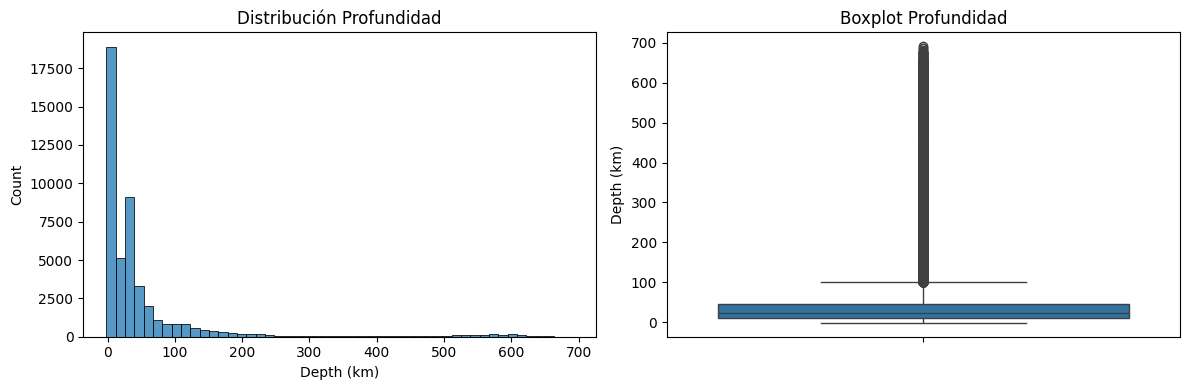

In [18]:
#Profundidad
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_desastres['Depth (km)'], bins=50, ax=axes[0])
axes[0].set_title('Distribución Profundidad')

sns.boxplot(df_desastres['Depth (km)'], ax=axes[1])
axes[1].set_title('Boxplot Profundidad')

plt.tight_layout()
plt.show()

### 7.2 Magnitud Richter

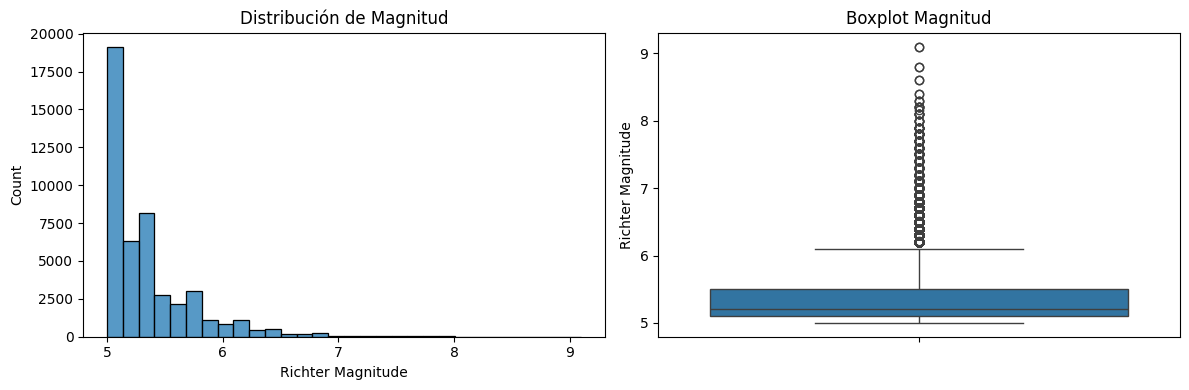

In [19]:
#Magnitud en escala Richter
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_desastres['Richter Magnitude'], bins=30, ax=axes[0])
axes[0].set_title('Distribución de Magnitud')

sns.boxplot(df_desastres['Richter Magnitude'], ax=axes[1])
axes[1].set_title('Boxplot Magnitud')

plt.tight_layout()
plt.show()

### 7.3 Frecuencia temporal anual

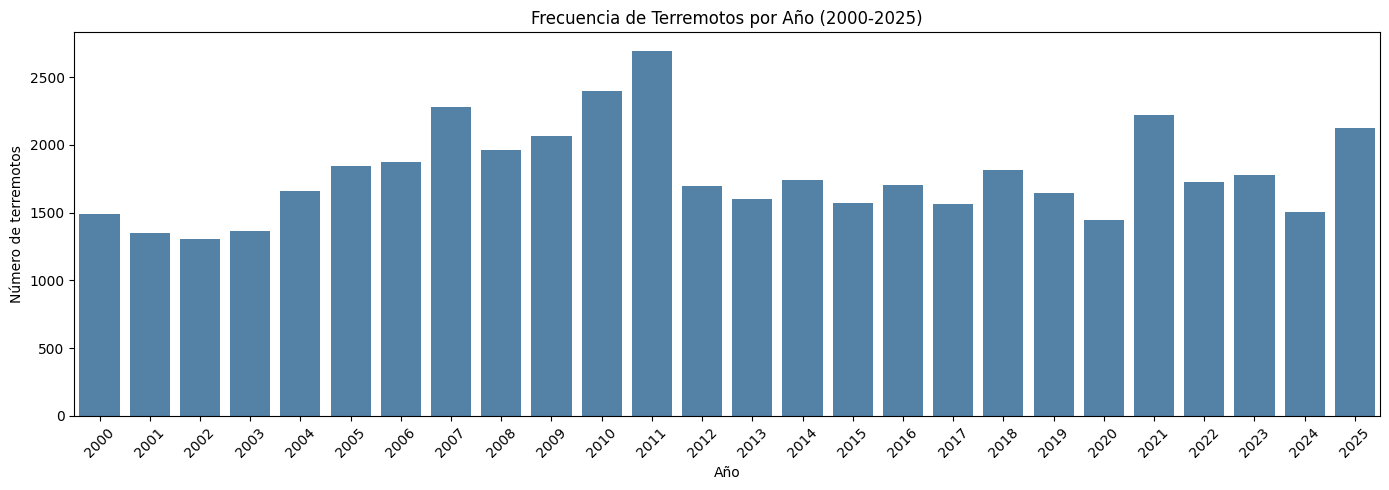

In [20]:
#Frecuencia temporal anual
df_desastres['year'] = df_desastres['Date'].dt.year

terremotos_año = df_desastres.groupby('year').size()

plt.figure(figsize=(14, 5))
sns.barplot(x=terremotos_año.index, y=terremotos_año.values, color='steelblue')
plt.title('Frecuencia de Terremotos por Año (2000-2025)')
plt.xlabel('Año')
plt.ylabel('Número de terremotos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7.4 Distribución geográfica

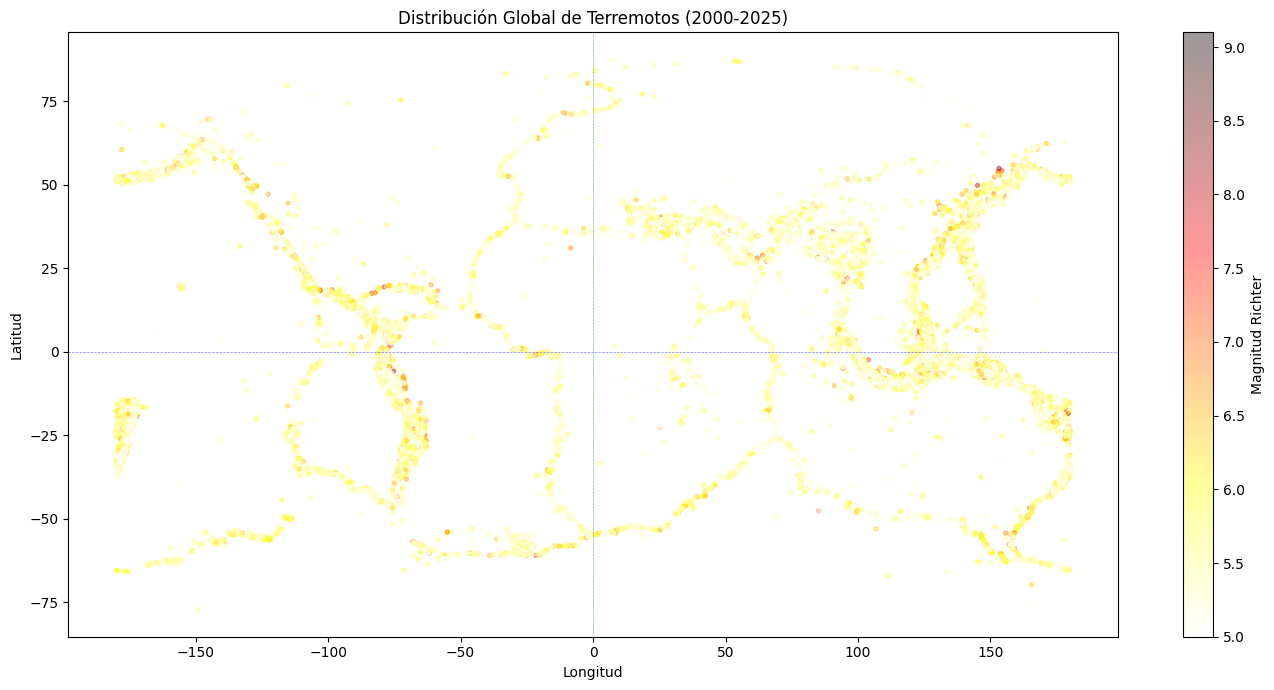

In [21]:
#Distribución geográfica: latitud y longitud
plt.figure(figsize=(14, 7))
scatter = plt.scatter(
    df_desastres['Longitude'],
    df_desastres['Latitude'],
    c=df_desastres['Richter Magnitude'],
    cmap='hot_r',
    alpha=0.4,
    s=8
)
plt.colorbar(scatter, label='Magnitud Richter')
plt.title('Distribución Global de Terremotos (2000-2025)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.axhline(y=0, color='blue', linewidth=0.5, linestyle='--', alpha=0.5)
plt.axvline(x=0, color='green', linewidth=0.5, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. Análisis bivariante

### 8.1 Profundidad vs. Magnitud (Hipótesis 2)


**Hipótesis:** *«Los terremotos de mayor magnitud (≥7.0) se producen con mayor frecuencia a profundidades intermedias (70–300 km) que a profundidades superficiales (<70 km), donde predominan los de menor magnitud.»*

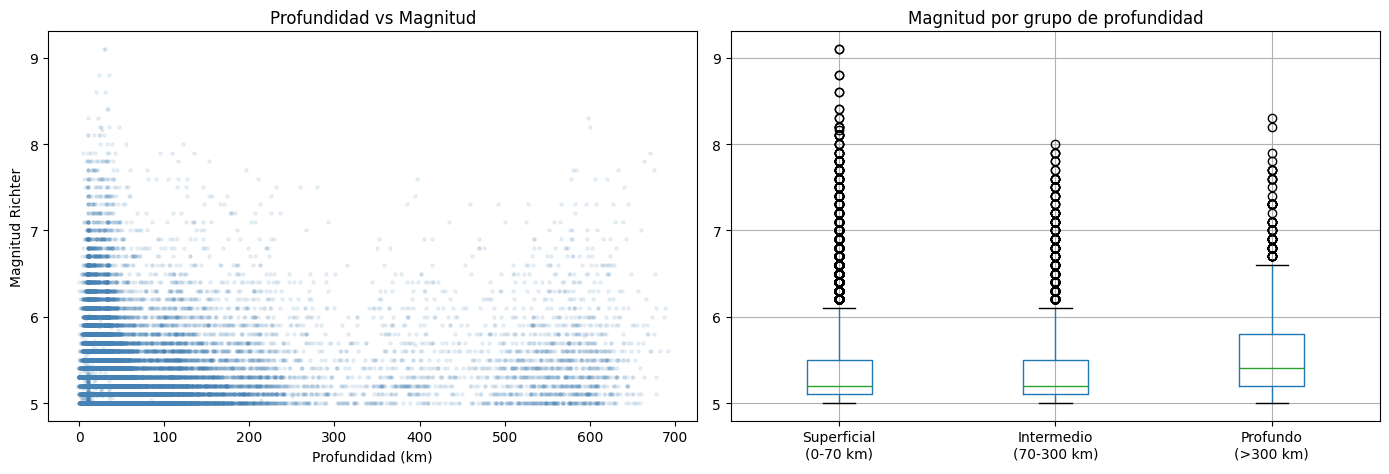

In [22]:
#Profundidad y Magnitud en Richter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Scatter plot
axes[0].scatter(
    df_desastres['Depth (km)'],
    df_desastres['Richter Magnitude'],
    alpha=0.1, s=5, color='steelblue'
)
axes[0].set_xlabel('Profundidad (km)')
axes[0].set_ylabel('Magnitud Richter')
axes[0].set_title('Profundidad vs Magnitud')

#Boxplot por grupos de profundidad
df_desastres['prof_grupo'] = pd.cut(
    df_desastres['Depth (km)'],
    bins=[0, 70, 300, 700],
    labels=['Superficial\n(0-70 km)', 'Intermedio\n(70-300 km)', 'Profundo\n(>300 km)']
)

df_desastres.boxplot(
    column='Richter Magnitude',
    by='prof_grupo',
    ax=axes[1]
)
axes[1].set_title('Magnitud por grupo de profundidad')
axes[1].set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [23]:
#Correlación y media por grupo de profundidad
corr = df_desastres['Depth (km)'].corr(df_desastres['Richter Magnitude'])
print(f"Correlación profundidad-magnitud: {corr:.3f}")

print("\nMedia de magnitud por grupo de profundidad:")
print(df_desastres.groupby('prof_grupo', observed=True)['Richter Magnitude'].mean().round(3))

Correlación profundidad-magnitud: 0.088

Media de magnitud por grupo de profundidad:
prof_grupo
Superficial\n(0-70 km)     5.339
Intermedio\n(70-300 km)    5.337
Profundo\n(>300 km)        5.539
Name: Richter Magnitude, dtype: float64


## 8.2 Tendencia de frecuencia anual (Hipótesis 1)

**Hipótesis:** *«La frecuencia de terremotos de magnitud ≥6.0 registrados globalmente entre 2000 y 2025 no muestra una tendencia de aumento significativa, siendo la variación interanual atribuible a factores aleatorios.»*

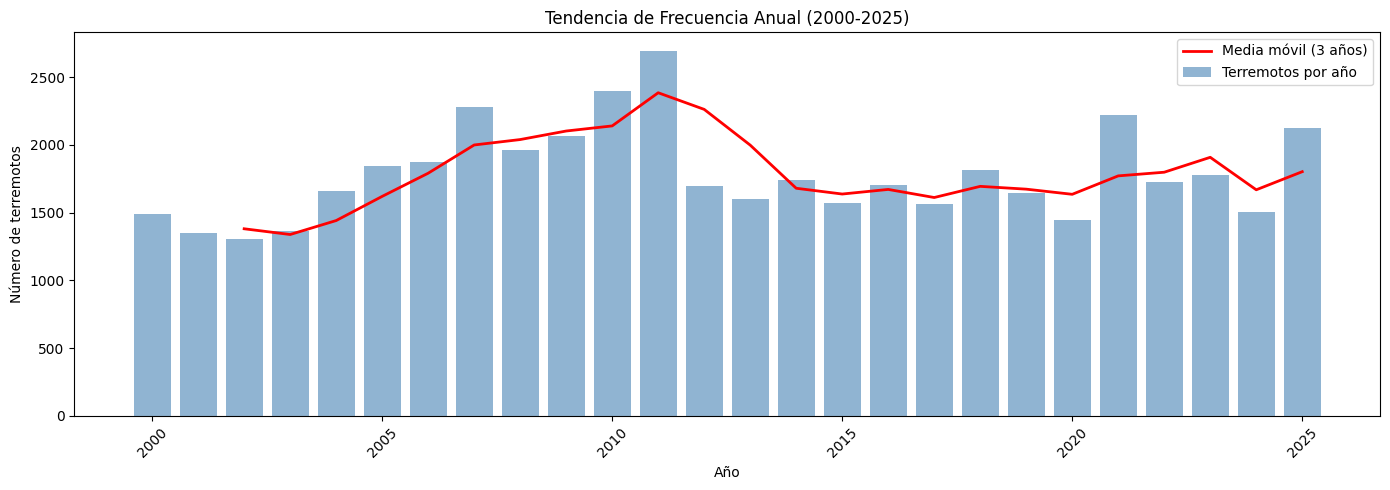

In [24]:
#Tendencia de frecuencia anual con media móvil
terremotos_año = df_desastres.groupby('year').size().reset_index()
terremotos_año.columns = ['year', 'count']
terremotos_año['media_movil'] = terremotos_año['count'].rolling(window=3).mean()

plt.figure(figsize=(14, 5))
plt.bar(terremotos_año['year'], terremotos_año['count'],
        color='steelblue', alpha=0.6, label='Terremotos por año')
plt.plot(terremotos_año['year'], terremotos_año['media_movil'],
         color='red', linewidth=2, label='Media móvil (3 años)')
plt.title('Tendencia de Frecuencia Anual (2000-2025)')
plt.xlabel('Año')
plt.ylabel('Número de terremotos')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Análisis multivariante

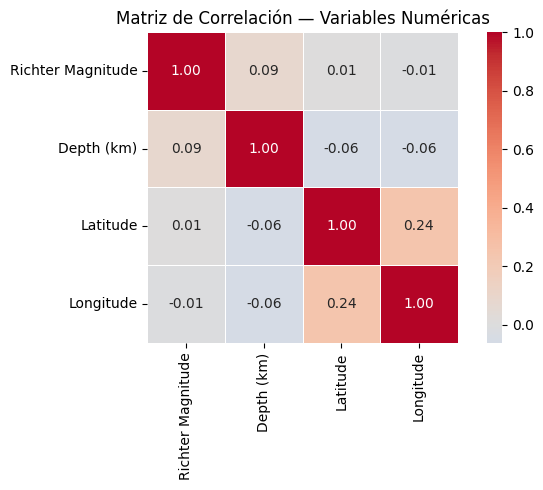

In [25]:
#Heatmap de correlación entre variables numéricas
plt.figure(figsize=(7, 5))
corr_matrix = df_desastres[['Richter Magnitude', 'Depth (km)', 'Latitude', 'Longitude']].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Matriz de Correlación — Variables Numéricas')
plt.tight_layout()
plt.show()

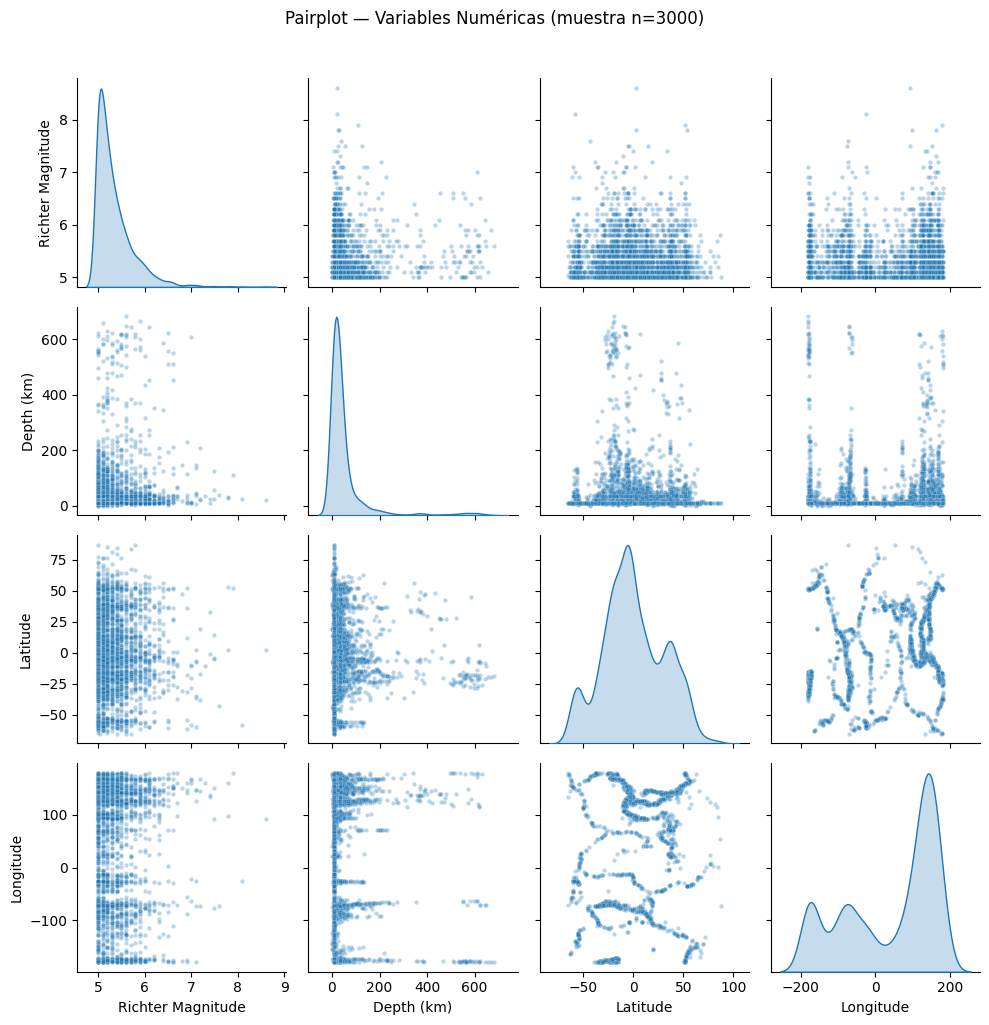

In [26]:
#Pairplot: relaciones entre todas las variables numéricas
# (muestra solo una muestra aleatoria para no saturar el gráfico)
df_sample = df_desastres[['Richter Magnitude', 'Depth (km)', 'Latitude', 'Longitude']].sample(
    n=3000, random_state=42
)

sns.pairplot(df_sample, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pairplot — Variables Numéricas (muestra n=3000)', y=1.02)
plt.tight_layout()
plt.show()

## 10. Verificación de Hipótesis 3 — Concentración geográfica (Cinturón de Fuego)

**Hipótesis:** *«Más del 70% de los terremotos de magnitud ≥6.0 ocurren dentro del Cinturón de Fuego del Pacífico (longitudes entre -180° y -60° O y 100° a 180° E, latitudes entre -60° y 60°).»*

In [27]:
#Filtramos terremotos de magnitud >= 6.0
df_mag6 = df_desastres[df_desastres['Richter Magnitude'] >= 6.0].copy()
print(f"Terremotos de magnitud >= 6.0: {len(df_mag6):,}")

Terremotos de magnitud >= 6.0: 3,870


In [28]:
#Definimos una función que determina si un punto está en el Cinturón de Fuego
# El Cinturón de Fuego rodea el Pacífico en dos grandes arcos:
#   - Arco Este: costa oeste de América --> longitud [-180, -60], latitud [-60, 60]
#   - Arco Oeste: Asia y Oceanía        --> longitud [100, 180],  latitud [-60, 60]

def en_cinturon_fuego(lat, lon):
    arco_este  = (-180 <= lon <= -60) and (-60 <= lat <= 60)
    arco_oeste = ( 100 <= lon <= 180) and (-60 <= lat <= 60)
    return arco_este or arco_oeste

df_mag6['cinturon_fuego'] = df_mag6.apply(
    lambda r: en_cinturon_fuego(r['Latitude'], r['Longitude']), axis=1
)

#Porcentaje dentro y fuera del Cinturón de Fuego
pct_cinturon = df_mag6['cinturon_fuego'].mean() * 100
pct_fuera    = 100 - pct_cinturon

print(f"Dentro del Cinturón de Fuego:  {df_mag6['cinturon_fuego'].sum():,} ({pct_cinturon:.1f}%)")
print(f"Fuera del Cinturón de Fuego:   {(~df_mag6['cinturon_fuego']).sum():,} ({pct_fuera:.1f}%)")

Dentro del Cinturón de Fuego:  3,185 (82.3%)
Fuera del Cinturón de Fuego:   685 (17.7%)


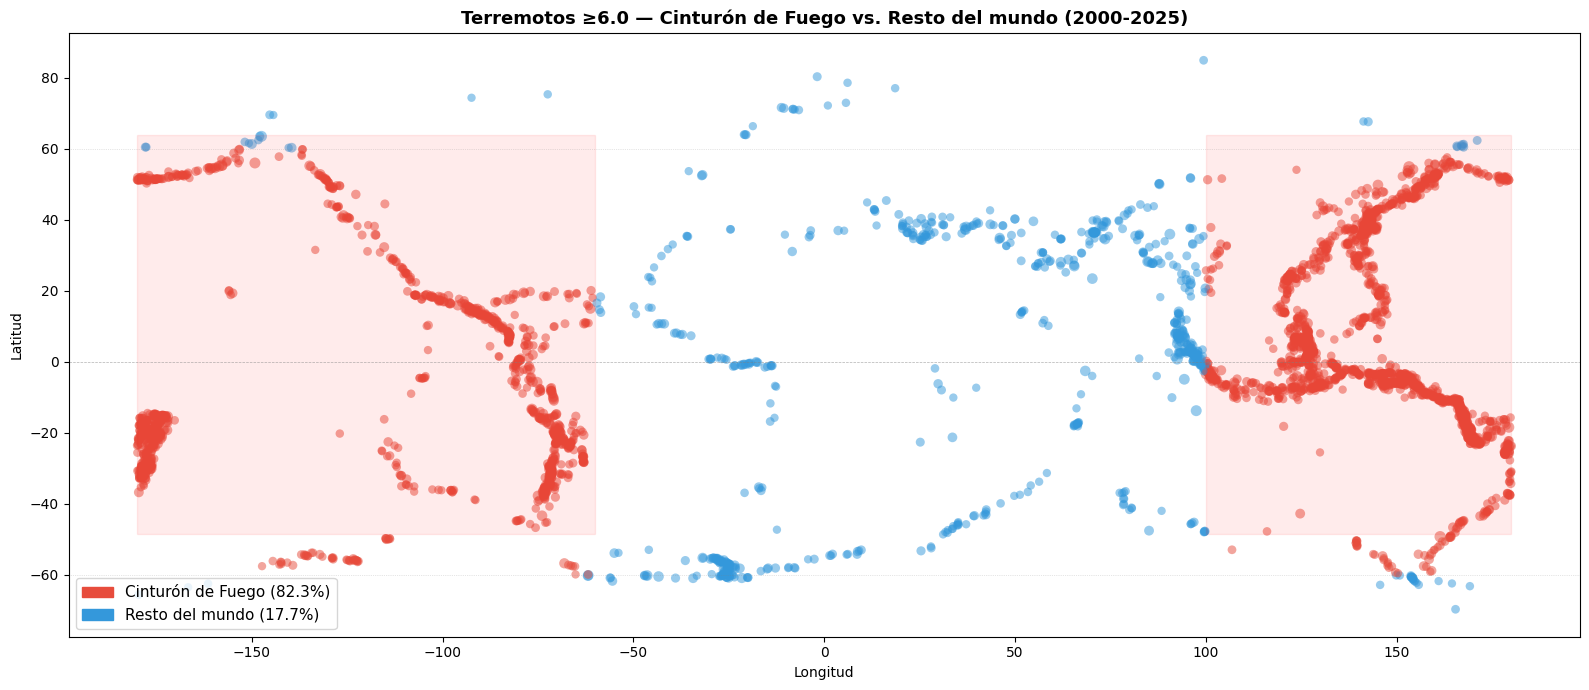

In [29]:
#Gráfico 1: Mapa de dispersión diferenciando dentro/fuera del Cinturón de Fuego
fig, ax = plt.subplots(figsize=(16, 7))

colores = df_mag6['cinturon_fuego'].map({True: '#e74c3c', False: '#3498db'})

ax.scatter(
    df_mag6['Longitude'],
    df_mag6['Latitude'],
    c=colores,
    alpha=0.5,
    s=df_mag6['Richter Magnitude'] ** 2,   # tamaño proporcional a la magnitud
    linewidths=0
)

#Sombreamos el Cinturón de Fuego (arco Este y arco Oeste)
ax.axvspan(-180, -60, ymin=0.17, ymax=0.83, alpha=0.08, color='red', label='_nolegend_')
ax.axvspan( 100,  180, ymin=0.17, ymax=0.83, alpha=0.08, color='red', label='_nolegend_')

#Leyenda manual
parche_dentro = mpatches.Patch(color='#e74c3c', label=f'Cinturón de Fuego ({pct_cinturon:.1f}%)')
parche_fuera  = mpatches.Patch(color='#3498db', label=f'Resto del mundo ({pct_fuera:.1f}%)')
ax.legend(handles=[parche_dentro, parche_fuera], fontsize=11, loc='lower left')

ax.set_title('Terremotos ≥6.0 — Cinturón de Fuego vs. Resto del mundo (2000-2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.axhline(y=0,  color='grey', linewidth=0.5, linestyle='--', alpha=0.6)
ax.axhline(y=60, color='grey', linewidth=0.5, linestyle=':', alpha=0.4)
ax.axhline(y=-60,color='grey', linewidth=0.5, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

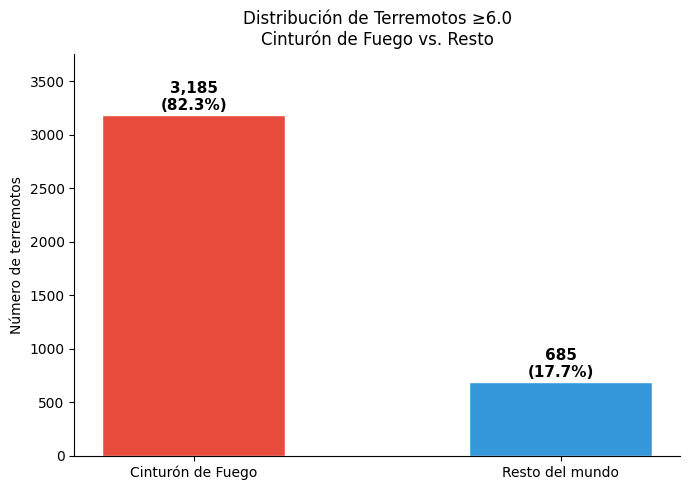

In [30]:
#Gráfico 2: Barras — proporción dentro / fuera del Cinturón
conteo = df_mag6['cinturon_fuego'].value_counts()
etiquetas = ['Cinturón de Fuego', 'Resto del mundo']
valores   = [conteo[True], conteo[False]]
colores_bar = ['#e74c3c', '#3498db']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(etiquetas, valores, color=colores_bar, edgecolor='white', width=0.5)

for bar, val, pct in zip(bars, valores, [pct_cinturon, pct_fuera]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Distribución de Terremotos ≥6.0\nCinturón de Fuego vs. Resto', fontsize=12)
ax.set_ylabel('Número de terremotos')
ax.set_ylim(0, max(valores) * 1.18)
sns.despine()
plt.tight_layout()
plt.show()

In [31]:
#Conclusión Hipótesis 3
umbral = 70.0
print("=" * 55)
print(f"  Hipótesis 3 — Concentración en el Cinturón de Fuego")
print("=" * 55)
print(f"  Terremotos ≥6.0 analizados : {len(df_mag6):,}")
print(f"  % en Cinturón de Fuego     : {pct_cinturon:.1f}%")
print(f"  Umbral hipótesis            : {umbral:.0f}%")
print()
if pct_cinturon > umbral:
    print(f"HIPÓTESIS CONFIRMADA: el {pct_cinturon:.1f}% supera el umbral del {umbral:.0f}%.")
else:
    print(f"HIPÓTESIS REFUTADA: el {pct_cinturon:.1f}% no alcanza el umbral del {umbral:.0f}%.")
print("=" * 55)

  Hipótesis 3 — Concentración en el Cinturón de Fuego
  Terremotos ≥6.0 analizados : 3,870
  % en Cinturón de Fuego     : 82.3%
  Umbral hipótesis            : 70%

HIPÓTESIS CONFIRMADA: el 82.3% supera el umbral del 70%.


## 11. Verificación de Hipótesis 4 — Patrones estacionales

**Hipótesis:** *«La distribución mensual de terremotos significativos (≥6.0) esuniforme a lo largo del año, sin concentración en ningún trimestre concreto.»*

In [32]:
#Extraemos el mes y agrupamos
df_mag6['month'] = df_mag6['Date'].dt.month
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

conteo_mensual = df_mag6.groupby('month').size().reset_index(name='count')
conteo_mensual['mes_nombre'] = nombres_meses

print(conteo_mensual.to_string(index=False))
print()
print(f"Media mensual  : {conteo_mensual['count'].mean():.1f}")
print(f"Desv. típica   : {conteo_mensual['count'].std():.1f}")
print(f"Coef. variación: {conteo_mensual['count'].std() / conteo_mensual['count'].mean() * 100:.1f}%")

 month  count mes_nombre
     1    317        Ene
     2    286        Feb
     3    362        Mar
     4    377        Abr
     5    298        May
     6    283        Jun
     7    311        Jul
     8    319        Ago
     9    333        Sep
    10    323        Oct
    11    355        Nov
    12    306        Dic

Media mensual  : 322.5
Desv. típica   : 29.6
Coef. variación: 9.2%


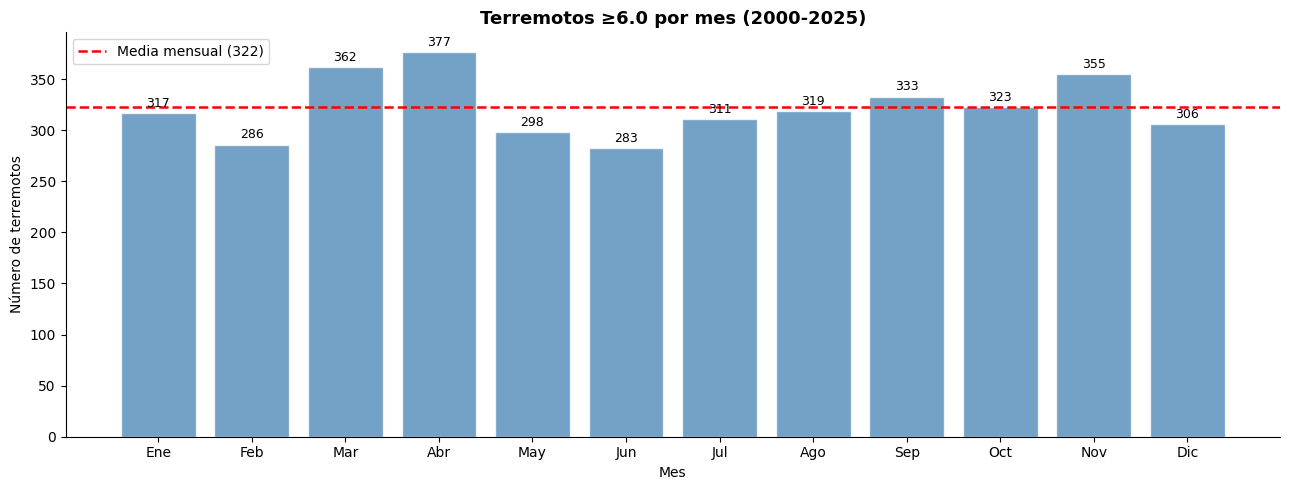

In [33]:
#Gráfico 1: Barras mensuales con línea de la media
media_mensual = conteo_mensual['count'].mean()

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(conteo_mensual['mes_nombre'], conteo_mensual['count'],
              color='steelblue', alpha=0.75, edgecolor='white')

#Línea de la media esperada bajo uniformidad
ax.axhline(y=media_mensual, color='red', linewidth=1.8,
           linestyle='--', label=f'Media mensual ({media_mensual:.0f})')

#Etiquetas encima de cada barra
for bar, val in zip(bars, conteo_mensual['count']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontsize=9)

ax.set_title('Terremotos ≥6.0 por mes (2000-2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Número de terremotos')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

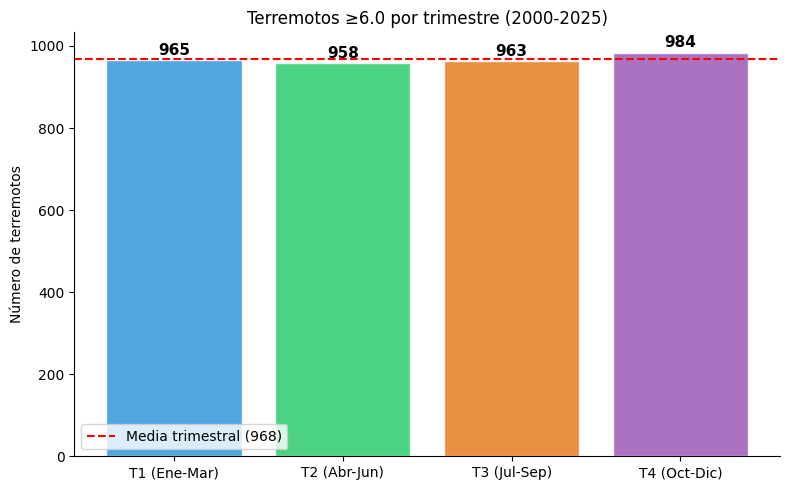

In [34]:
#Gráfico 2: Distribución trimestral
trimestres = {
    'T1 (Ene-Mar)': [1, 2, 3],
    'T2 (Abr-Jun)': [4, 5, 6],
    'T3 (Jul-Sep)': [7, 8, 9],
    'T4 (Oct-Dic)': [10, 11, 12]
}

conteo_trim = {
    nombre: df_mag6[df_mag6['month'].isin(meses)].shape[0]
    for nombre, meses in trimestres.items()
}

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(conteo_trim.keys(), conteo_trim.values(),
       color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6'],
       edgecolor='white', alpha=0.85)

media_trim = sum(conteo_trim.values()) / 4
ax.axhline(y=media_trim, color='red', linewidth=1.5,
           linestyle='--', label=f'Media trimestral ({media_trim:.0f})')

for nombre, val in conteo_trim.items():
    ax.text(list(conteo_trim.keys()).index(nombre),
            val + 5, str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Terremotos ≥6.0 por trimestre (2000-2025)', fontsize=12)
ax.set_ylabel('Número de terremotos')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [35]:
#Test estadístico: Chi-cuadrado de bondad de ajuste
# Contrasta si los conteos mensuales son compatibles con una distribución uniforme
frecuencias_observadas = conteo_mensual['count'].values
chi2_stat, p_valor = stats.chisquare(frecuencias_observadas)

print(f"Estadístico Chi²  : {chi2_stat:.3f}")
print(f"Valor p           : {p_valor:.4f}")
print()
if p_valor > 0.05:
    print("No se rechaza H₀ (p > 0.05): la distribución mensual es compatible")
    print("con la uniformidad. La hipótesis se CONFIRMA.")
else:
    print("Se rechaza H₀ (p ≤ 0.05): existen diferencias estadísticamente")
    print("significativas entre meses. La hipótesis se REFUTA.")

Estadístico Chi²  : 29.882
Valor p           : 0.0017

Se rechaza H₀ (p ≤ 0.05): existen diferencias estadísticamente
significativas entre meses. La hipótesis se REFUTA.


In [36]:
#Conclusión Hipótesis 4
print("=" * 60)
print(" Hipótesis 4 — Patrones estacionales")
print("=" * 60)
print(f"Terremotos ≥6.0 analizados : {len(df_mag6):,}")
print(f" Chi² = {chi2_stat:.3f}  |  p-valor = {p_valor:.4f}")
print()
print("Interpretación:")
print("El coeficiente de variación mensual es ~9%, lo que indica")
print("variaciones pequeñas. Sin embargo, el test Chi² (p=0.0017)")
print("detecta diferencias estadísticamente significativas.")
print()
print("Conclusión: la hipótesis se REFUTA formalmente, aunque las")
print("diferencias entre meses son modestas en términos prácticos.")
print("Los meses de marzo y abril concentran ligeramente más eventos.")
print("=" * 60)

 Hipótesis 4 — Patrones estacionales
Terremotos ≥6.0 analizados : 3,870
 Chi² = 29.882  |  p-valor = 0.0017

Interpretación:
El coeficiente de variación mensual es ~9%, lo que indica
variaciones pequeñas. Sin embargo, el test Chi² (p=0.0017)
detecta diferencias estadísticamente significativas.

Conclusión: la hipótesis se REFUTA formalmente, aunque las
diferencias entre meses son modestas en términos prácticos.
Los meses de marzo y abril concentran ligeramente más eventos.
